## qBraid Runtime: Bloqade batch submission to QuEra Aquila

In [1]:
%%capture

%pip install 'qbraid[bloqade,braket,visualization]'

In [2]:
import numpy as np
from bloqade.analog import var
from bloqade.analog.atom_arrangement import Square

from qbraid.runtime import QbraidProvider
from qbraid.visualization import plot_histogram, plot_runtime_conversion_scheme

/Users/tarinihardikar/Desktop/qBraid-software/qbraid-lab-demo/.demo/lib/python3.12/site-packages/bloqade/analog/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Create adiabatic program batch using Bloqade

In [3]:
adiabatic_durations = [0.4, 3.2, 0.4]

max_detuning = var("max_detuning")
adiabatic_program = (
    Square(3, lattice_spacing="lattice_spacing")
    .rydberg.rabi.amplitude.uniform.piecewise_linear(
        durations=adiabatic_durations, values=[0.0, "max_rabi", "max_rabi", 0.0]
    )
    .detuning.uniform.piecewise_linear(
        durations=adiabatic_durations,
        values=[
            -max_detuning,  # scalar variables support direct arithmetic operations
            -max_detuning,
            max_detuning,
            max_detuning,
        ],
    )
    .assign(max_rabi=15.8, max_detuning=16.33)
    .batch_assign(lattice_spacing=np.arange(4.0, 7.0, 1.0))
)

Target QuEra Aquila device using QbraidProvider

In [4]:
provider = QbraidProvider()

In [6]:
device = provider.get_device("aws:quera:qpu:aquila")

print(device.status())
print(device.profile.experiment_type)
print(device.profile.program_spec)

DeviceStatus.ONLINE
ExperimentType.ANALOG
ProgramSpec(AnalogHamiltonianSimulation, braket_ahs)


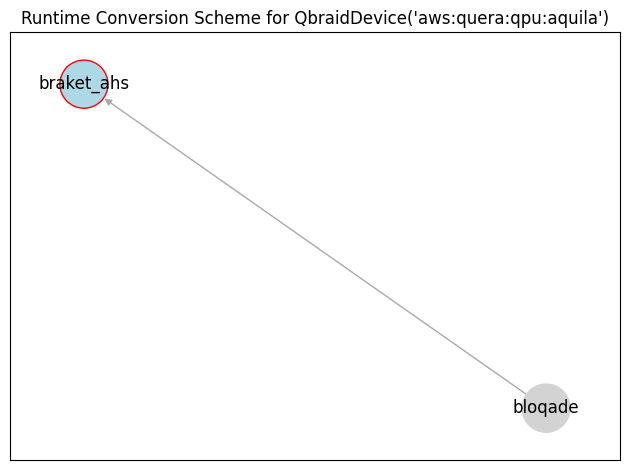

In [7]:
plot_runtime_conversion_scheme(device)

Submit quantum task(s)

In [8]:
job_batch = device.run(adiabatic_program, shots=10, tags={"batch": "adiabatic-test-1"})

/Users/tarinihardikar/Desktop/qBraid-software/qbraid-lab-demo/.demo/lib/python3.12/site-packages/bloqade/analog/submission/braket.py:45: UserWarning: Could not retrieve device capabilities from braket API. Using local capabilities file for Aquila.
  warnings.warn(


In [9]:
print(f"{'Job Id':<60} {'Status':<15} {'Queue Position':<5}")
print("-" * 50)
for job in job_batch:
    print(f"{job.id:<60} {job.status():<15} {job.queue_position():<5}")

Job Id                                                       Status          Queue Position
--------------------------------------------------
aws:quera:qpu:aquila-9c4c-qjob-69a22ad04bb4017ebdf5fc80      JobStatus.QUEUED 9    
aws:quera:qpu:aquila-9c4c-qjob-69a22ad04bb4017ebdf5fc83      JobStatus.QUEUED 10   
aws:quera:qpu:aquila-9c4c-qjob-69a22ad14bb4017ebdf5fc86      JobStatus.QUEUED 11   


In [1]:
results = [job.result() for job in job_batch]

shot_results_batch = [result.data.measurements for result in results]

counts_batch = [result.data.measurement_counts for result in results]

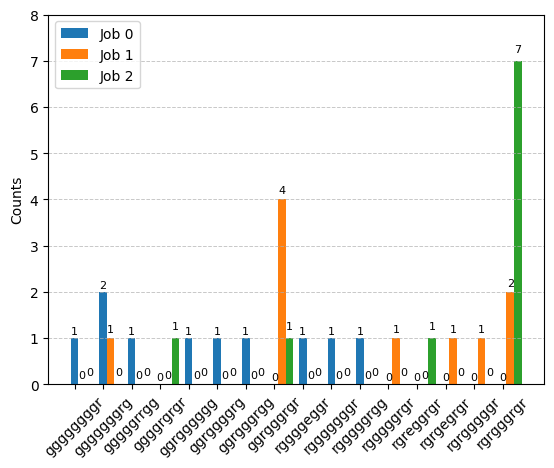

In [12]:
plot_histogram(counts_batch)